In [1]:
import pandas as pd

def read(sheet_name, file_name='results.xlsx'):
    # 读取 Excel 文件
    df = pd.read_excel(file_name, sheet_name=sheet_name)
    # 前向填充空白的 HyperParameter 名称
    df['HyperParameters'] = df['HyperParameters'].ffill()
    return df
# 整体结果
hps = ["conv2d", "max_pool2d", "linear"]
avgs = []

for hp in hps:
    df = read(hp)
    avg_df = df.groupby('HyperParameters')[['TEST_ACC', 'TEST_F1', 'TEST_R', 'TEST_P']].mean().reset_index()
    avg_df['layer'] = hp  # 添加一个来源字段
    avgs.append(avg_df)  # 注意这里是 append，不是 extend

combine = pd.concat(avgs, ignore_index=True)
print(combine)
with pd.ExcelWriter("table.xlsx", if_sheet_exists="error", mode="a") as writer:
    combine.to_excel(writer ,sheet_name="overall")


  HyperParameters  TEST_ACC  TEST_F1   TEST_R   TEST_P       layer
0     kernel_size   99.7666  99.7662  99.7666  99.7670      conv2d
1    out_channels   91.8696  91.6214  91.8696  92.7198      conv2d
2          stride   98.2860  98.4008  98.2860  98.6900      conv2d
3     kernel_size   99.9990  99.9990  99.9990  99.9990  max_pool2d
4         padding   99.9990  99.9990  99.9990  99.9990  max_pool2d
5    out_channels   99.9868  99.9868  99.9868  99.9868      linear


ValueError: Sheet 'overall' already exists and if_sheet_exists is set to 'error'.

In [2]:
# 对比结果
df = read("conv2d_T", file_name="results_baseline.xlsx")
baseline_df = df.groupby('HyperParameters')[['TEST_ACC', 'TEST_F1', 'TEST_R', 'TEST_P']].mean().reset_index()
print(baseline_df)
mine = [combine.iloc[1]["TEST_ACC"], combine.iloc[0]["TEST_F1"], combine.iloc[2]["TEST_F1"]]
baseline = [baseline_df.iloc[1]["TEST_ACC"], baseline_df.iloc[0]["TEST_F1"], baseline_df.iloc[2]["TEST_F1"]]
print(mine, baseline)


  HyperParameters  TEST_ACC  TEST_F1   TEST_R   TEST_P
0     kernel_size   99.4810   99.486  99.4810  99.4998
1    out_channels   83.3144    0.000   0.0000   0.0000
2          stride   97.5574   97.538  97.5574  97.6276
[np.float64(91.8696), np.float64(99.7662), np.float64(98.4008)] [np.float64(83.3144), np.float64(99.486), np.float64(97.538)]


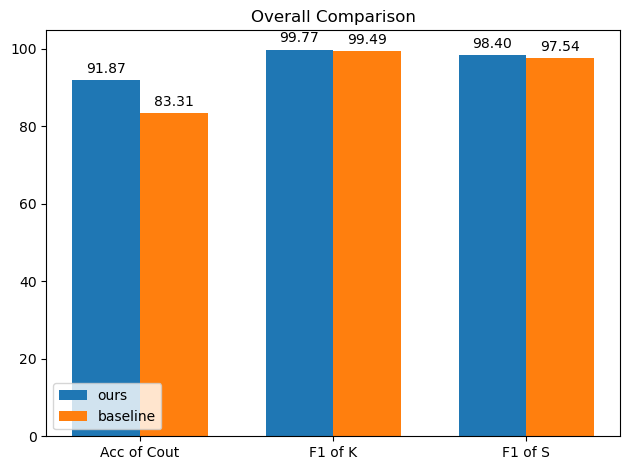

In [3]:
import numpy as np
import matplotlib.pyplot as plt
labels = ['Acc of Cout', 'F1 of K', 'F1 of S']  # 你可以改成更具体的名字

x = np.arange(len(labels))  # 标签的位置
width = 0.35  # 柱宽

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, mine, width, label='ours')
rects2 = ax.bar(x + width/2, baseline, width, label='baseline')

# 添加标签和标题
ax.set_title("Overall Comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc="lower left")

# 给柱子上加数值标签
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [69]:
df_ours = read(sheet_name="conv2d", file_name="results.xlsx")
df_baseline = read(sheet_name="conv2d_T", file_name="results_baseline.xlsx")
# print(df_baseline)
acc_oc_ours = df_ours.iloc[5:10]["TEST_ACC"].to_numpy()
f1_k_ours = df_ours.iloc[:5]["TEST_F1"].to_numpy()
acc_oc_baseline = df_baseline.iloc[5:10]["TEST_ACC"].to_numpy()
f1_k_baseline = df_baseline.iloc[:5]["TEST_F1"].to_numpy()
diff_oc = acc_oc_ours-acc_oc_baseline
diff_k = f1_k_ours - f1_k_baseline
xlabel = ["160", "192", "224", "299", "331"]
df_oc = pd.DataFrame({
    "Ours":acc_oc_ours,
    "Baseline":acc_oc_baseline,
    "Diff":diff_oc
}, index=xlabel)
df_k = pd.DataFrame({
    "Ours":f1_k_ours,
    "Baseline":f1_k_baseline,
    "Diff":diff_k
}, index=xlabel)
print(df_oc.T)
print(df_k.T)
with pd.ExcelWriter("table.xlsx", if_sheet_exists="error", mode="a") as writer:
    df_oc.T.to_excel(writer, sheet_name="test_domain_oc", )
    df_k.T.to_excel(writer, sheet_name="test_domain_k")


             160     192     224     299     331
Ours      94.350  97.671  95.095  76.262  95.970
Baseline  90.808  91.560  91.857  54.616  87.731
Diff       3.542   6.111   3.238  21.646   8.239
             160     192     224     299     331
Ours      99.977  99.989  99.886  99.075  99.904
Baseline  99.471  99.851  99.399  99.916  98.793
Diff       0.506   0.138   0.487  -0.841   1.111


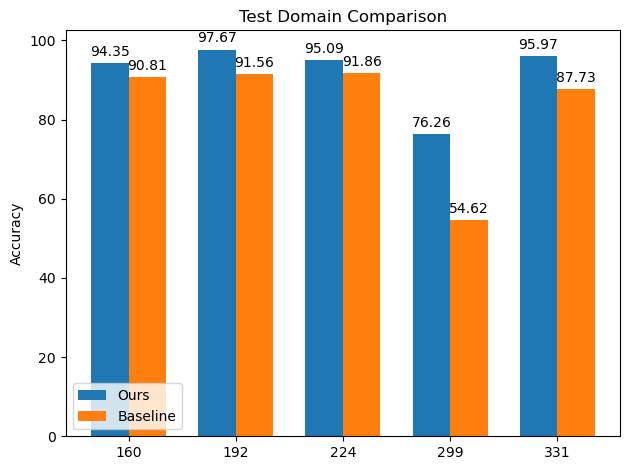

In [61]:
x = np.arange(len(acc_oc_ours))  # x轴刻度（0~4）
width = 0.35  # 柱状图宽度

fig, ax1 = plt.subplots()  # 上下两个子图

# ======= 子图1：ACC =======
rects1 = ax1.bar(x - width/2, acc_oc_ours, width, label='Ours')
rects2 = ax1.bar(x + width/2, acc_oc_baseline, width, label='Baseline')

ax1.set_title('Test Domain Comparison')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(x)
xlabel = ["160", "192", "224", "299", "331"]
ax1.set_xticklabels([i for i in xlabel])  # 改成你自己的标签
ax1.legend(loc='lower left')

# ======= 柱子上添加数值 =======
def autolabel(ax, rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(ax1, rects1)
autolabel(ax1, rects2)

plt.tight_layout()
plt.show()

In [76]:
def build_comparison_df(ours, baseline, labels=None):
    if labels is None:
        labels = ["160", "192", "224", "299", "331"]

    diff = ours - baseline

    df = pd.DataFrame({
        "Ours": ours,
        "Baseline": baseline,
        "Diff": diff
    }, index=labels)

    return df.T

In [84]:
# 源域数量
df_ours = read(sheet_name="conv2d_O", file_name="results.xlsx")
df_baseline = read(sheet_name="conv2d_O", file_name="results_baseline.xlsx")
# print(df_baseline)
acc_oc_ours = df_ours.iloc[4:8]["TEST_ACC"].to_numpy()
f1_s_ours = df_ours.iloc[8:12]["TEST_F1"].to_numpy()
acc_oc_baseline = df_baseline.iloc[4:8]["TEST_ACC"].to_numpy()
f1_s_baseline = df_baseline.iloc[8:12]["TEST_F1"].to_numpy()
labels = [str(i) for i in range(1,5)]
df_oc = build_comparison_df(acc_oc_ours, acc_oc_baseline, labels=labels)
df_s = build_comparison_df(f1_s_ours, f1_s_baseline, labels=labels)
print(df_oc,"\n", df_s)
with pd.ExcelWriter("table.xlsx", if_sheet_exists="replace", mode="a") as writer:
    df_oc.to_excel(writer, sheet_name="od_num_oc", )
    df_s.to_excel(writer, sheet_name="od_num_s")

               1       2       3       4
Ours      79.427  81.733  84.992  95.970
Baseline  62.172  71.545  81.320  87.731
Diff      17.255  10.188   3.672   8.239 
                1       2       3       4
Ours      97.469  98.388  98.508  99.931
Baseline  92.451  95.792  96.280  97.771
Diff       5.018   2.596   2.228   2.160


无论源域数量为多少都有i提升，
我们的方法并不依赖于多源数据的存在，即便在单一数据域下也能够显著提高模型的泛化能力
且随着源域数量减少，泛化难度a增加，对模型泛化能力的提高a更加显著

#RAPL
通过添加信号域数量可以提高模型的泛化能力，但提高的程度有限
在单信号域下，模型的泛化能力对信号域种类不敏感


#data ratio
分类模型对泛化能力的提高对数据规模不敏感
与分类模型相反，回归模型对更依赖数据量的充分性

# 消融实验
考虑到多个预测目标在模型中的结构和训练过程完全相同，且实验中各目标表现趋势一致，本文选取其中表现最明显的目标作为代表，进行消融实验分析。 
对于分类模型我们选取K进行实验，对于回归模型我们选取Oc
## 对于分类模型：
**将分类Loss中的Lvar去掉**
99.767 --》  
**将分类模块和分类Loss换成CELoss**

## 对于回归模型：
**将回归模块和回归Loss换成MSELoss**

## 对于特征编码器
四层Encoder与baseline保持一致，仅将模型中的线性层换为mlp
对于特征编码器，只将mlp换成linear层进行消融
**mlp换成linear**
